# xNES versus default CMA-ES: noisy BBOB landscapes

This study measures **the clean objective at the current mean** versus objective calls. Both optimizers see only noisy scores; oracle assessment never enters an update or stopping decision.

- Bare xNES and default pycma populations, identical zero start and isotropic scale 1.
- No wrapper resets, external restarts, explicit noise handling, or learning-rate tuning.
- Known BBOB landscapes with controlled noise—not the official `bbob-noisy` suite. [Function definitions](https://numbbo.github.io/coco/testsuites/bbob).
- Preview is exploratory; use the full preset for 15 instances and two optimizer seeds per case. No experiment can establish superiority outside its tested budgets and noise models.
- Every terminal status, warning, and exception is retained. A convergence-like stop can still have poor objective quality.

In [10]:
from pathlib import Path
from dataclasses import replace
import sys

# Works from either the repository root or notebooks/.
ROOT = Path.cwd() if (Path.cwd() / "leitwerk").is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
from IPython.display import display
from benchmarks.runner import PRESETS, CHECKPOINTS, create_run, run_study, run_stability, load_runs
from benchmarks.reporting import checkpoint_table, paired_summary, run_table, plot_quality, plot_targets, plot_stability

In [11]:
# Run All launches the preview, never the full study implicitly.
PRESET = "full"  # "full": 24 functions, d=2/5/10/20/30, 15 instances, two seeds, 10,000 calls
config = PRESETS[PRESET]
# Optional edits, e.g. config = replace(config, functions=(12, 15), dimensions=(10, 30))
LOAD_RUN = None  # Path("runs/<saved directory>") to regenerate reports without optimization
print({
    "preset": PRESET, "config": config,
    "optimizer_runs": config.runs,
    "maximum_objective_calls": config.runs * config.budget,
    "checkpoints": [n for n in CHECKPOINTS if n <= config.budget],
})
print("Stability runs are separate; the full preset can take a long time.")

{'preset': 'full', 'config': Study(functions=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24), dimensions=(2, 5, 10, 20, 30), instances=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15), repeats=2, budget=10000, noises=('clean', 'additive', 'heteroscedastic', 'outliers'), master_seed=1234), 'optimizer_runs': 28800, 'maximum_objective_calls': 288000000, 'checkpoints': [100, 300, 1000, 3000, 10000]}
Stability runs are separate; the full preset can take a long time.


In [12]:
# Noise definitions (s = max(initial clean gap, 1e-12); g = current clean gap):
# clean:           f
# additive:        f + 0.01*s*N(0,1)
# heteroscedastic: f + (0.1*g + 0.001*s)*N(0,1)
# outliers:        f + 0.01*s*N(0,1) + Bernoulli(0.01)*s*t(3)
#
# Random variates are paired by evaluation index, not by generation.
# Each optimizer uses its native population size. Only complete populations are told.
# The final remainder is unused; checkpoints use the latest completed update, never a future one.
#
# Clean assessment is outside the optimization budget and never consumes observation noise.
# Budgets count all attempted optimizer objective calls, including calls producing invalid values.
# The core's first terminal status ends the run; target attainment is assessed afterward.

In [13]:
if LOAD_RUN is None:
    run_dir = create_run(config)
    print("Writing incremental results to", run_dir)
    results = run_study(config, run_dir)
else:
    run_dir = Path(LOAD_RUN)
    results = load_runs(run_dir)
    print("Loaded", len(results), "runs from", run_dir)

runs = run_table(results)
print(f"Recorded run time: {runs.seconds.sum():.1f} s; objective calls: {runs.evaluations.sum():,}")
display(runs.groupby(["algorithm", "kind"], dropna=False).agg(
    runs=("problem", "size"), calls=("evaluations", "sum"), warnings=("warning_count", "sum")
))

Writing incremental results to C:\Users\volke\PycharmProjects\leitwerk\notebooks\runs\20260918T155841-0c58a2ba


Paired cases:   0%|          | 0/14400 [00:00<?, ?it/s]

NOTE (module=cma, iteration=258):  
condition in coordinate system exceeded 1.0e+08, rescaled to 1.0e+00, 
condition changed from 4.6e+09 to 1.1e+02
Recorded run time: 20638.8 s; objective calls: 227,139,974


runs      calls  warnings
algorithm kind                                         
cma       budget              5442   54399896      5461
          convergence         8884   39009664      9429
          numerical_failure     74     264290       148
xnes      budget             12634  126308732         0
          convergence         1765    7151608         0
          numerical_failure      1       5784         0

In [14]:
# Every failure/early stop remains visible; inspect a run's JSON for its saved pre-update state.
display(runs[runs.kind != "budget"][
    ["function", "dimension", "instance", "repeat", "noise", "algorithm",
     "kind", "reason", "evaluations", "unused_budget", "final_relative_gap", "warning_count"]
])
display(runs[runs.warning_count > 0][
    ["function", "dimension", "noise", "algorithm", "warning_messages"]
])
print("Numerical failures use their last finite state only for diagnosis, not as successful recommendations.")

,function,dimension,instance,repeat,noise,algorithm,kind,reason,evaluations,unused_budget,final_relative_gap,warning_count
0,1,2,1,0,clean,xnes,convergence,MEAN_STEP_MIN,1374,8626,0.000000,0
1,1,2,1,0,clean,cma,convergence,{'tolfun': 1e-11},456,9544,0.000000,1
3,1,2,1,0,additive,cma,convergence,{'tolstagnation': 146},3240,6760,0.000513,1
5,1,2,1,0,heteroscedastic,cma,convergence,{'tolstagnation': 146},3240,6760,0.000007,1
7,1,2,1,0,outliers,cma,convergence,{'tolstagnation': 146},3240,6760,0.000491,1
...,...,...,...,...,...,...,...,...,...,...,...,...
28461,24,20,9,1,heteroscedastic,cma,convergence,{'tolstagnation': 788},9420,580,0.949516,1
28471,24,20,10,0,outliers,cma,convergence,{'tolstagnation': 788},9840,160,0.803951,1
28475,24,20,10,1,additive,cma,convergence,{'tolstagnation': 788},9420,580,0.410839,1
28513,24,20,13,0,clean,cma,convergence,{'tolfun': 1e-11},9648,352,0.209138,1


,function,dimension,noise,algorithm,warning_messages
1,1,2,clean,cma,seed=2182800504 will never be used (seed is on...
3,1,2,additive,cma,seed=2182800504 will never be used (seed is on...
5,1,2,heteroscedastic,cma,seed=2182800504 will never be used (seed is on...
7,1,2,outliers,cma,seed=2182800504 will never be used (seed is on...
9,1,2,clean,cma,seed=2081010701 will never be used (seed is on...
...,...,...,...,...,...
28791,24,30,outliers,cma,seed=2314864222 will never be used (seed is on...
28793,24,30,clean,cma,seed=3609765934 will never be used (seed is on...
28795,24,30,additive,cma,seed=3609765934 will never be used (seed is on...
28797,24,30,heteroscedastic,cma,seed=3609765934 will never be used (seed is on...


Numerical failures use their last finite state only for diagnosis, not as successful recommendations.


In [15]:
checkpoints = checkpoint_table(results)
comparison = paired_summary(checkpoints)
# Positive median_log10_gap_ratio favors CMA; negative favors xNES.
# Intervals resample whole instances, retaining their repeated seeds together.
# They describe uncertainty of paired differences, not the spread of unrelated cases.
display(comparison)
print("Finite-only estimates must be read with excluded_pairs and each algorithm's failure count.")
print("Preview intervals use only three instances and should not support strong claims.")

,function,dimension,noise,budget,pairs,finite_pairs,excluded_pairs,xnes_failures,cma_failures,xnes_wins,cma_wins,ties_or_both_failed,median_log10_gap_ratio,ci_low,ci_high,instance_clusters
0,1,2,additive,100,30,30,0,0,0,14,16,0,0.007998,-0.163487,0.439244,15
1,1,2,additive,300,30,30,0,0,0,17,13,0,-0.116817,-0.559360,0.245020,15
2,1,2,additive,1000,30,30,0,0,0,16,14,0,-0.101104,-0.459759,0.105431,15
3,1,2,additive,3000,30,30,0,0,0,14,16,0,0.057524,-0.479559,0.263031,15
4,1,2,additive,10000,30,30,0,0,0,15,15,0,-0.003489,-0.515023,0.215724,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,24,30,outliers,100,30,30,0,0,0,15,15,0,0.005923,-0.026632,0.041938,15
2396,24,30,outliers,300,30,30,0,0,0,22,8,0,-0.029303,-0.063152,-0.011055,15
2397,24,30,outliers,1000,30,30,0,0,0,15,15,0,-0.003376,-0.043180,0.015860,15
2398,24,30,outliers,3000,30,30,0,0,0,19,11,0,-0.028149,-0.046304,0.003452,15


Finite-only estimates must be read with excluded_pairs and each algorithm's failure count.
Preview intervals use only three instances and should not support strong claims.


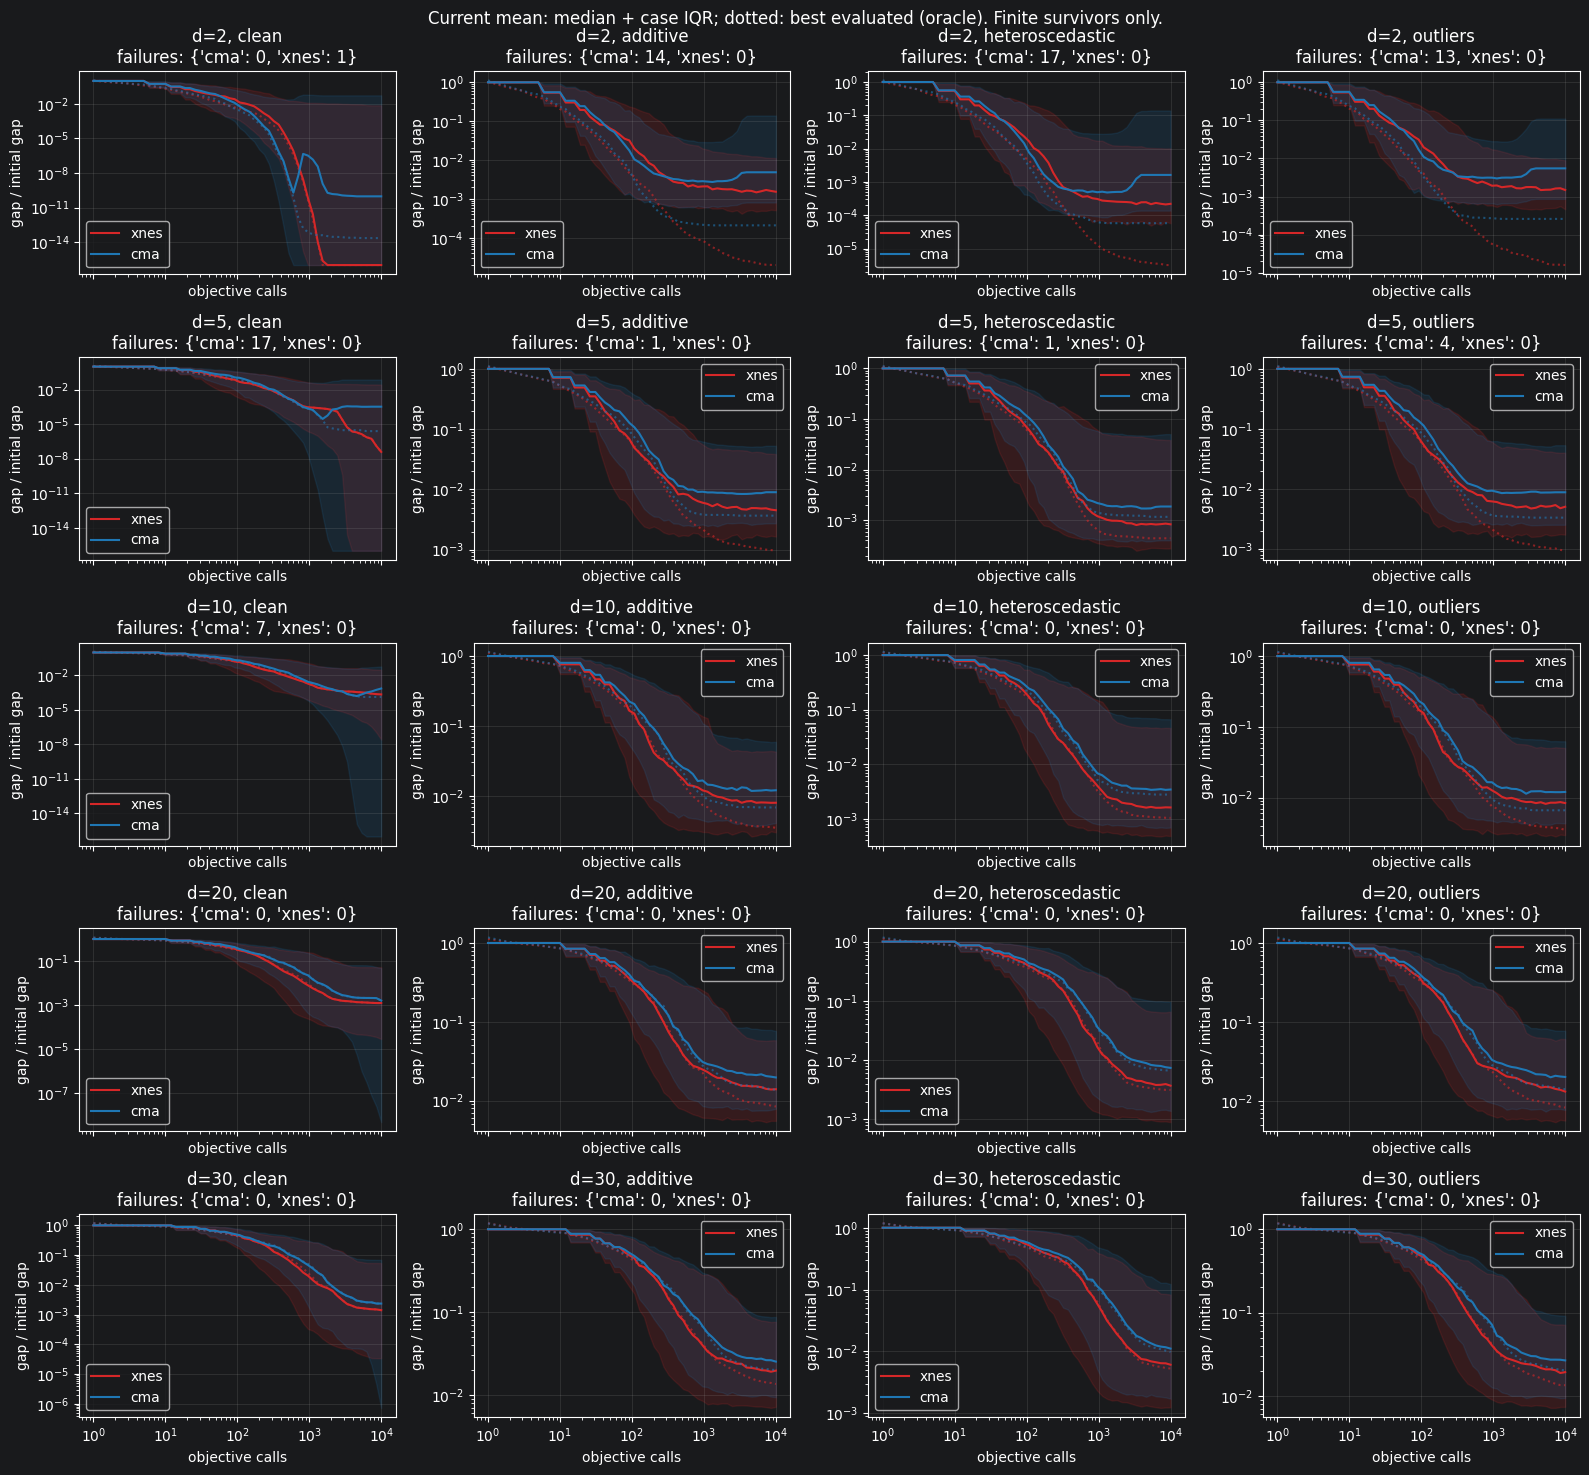

In [16]:
# Solid: current-mean median; band: case IQR (NOT a confidence interval).
# Dotted: best clean evaluated gap, an oracle diagnostic rather than a deployable recommendation.
# Finite stopped recommendations are carried forward and marked in the checkpoint table.
# Failed runs leave finite-quality curves at failure; failure counts are shown and retained in tables.
plot_quality(results)
plt.show()
# To inspect one landscape: plot_quality(results, function=12)

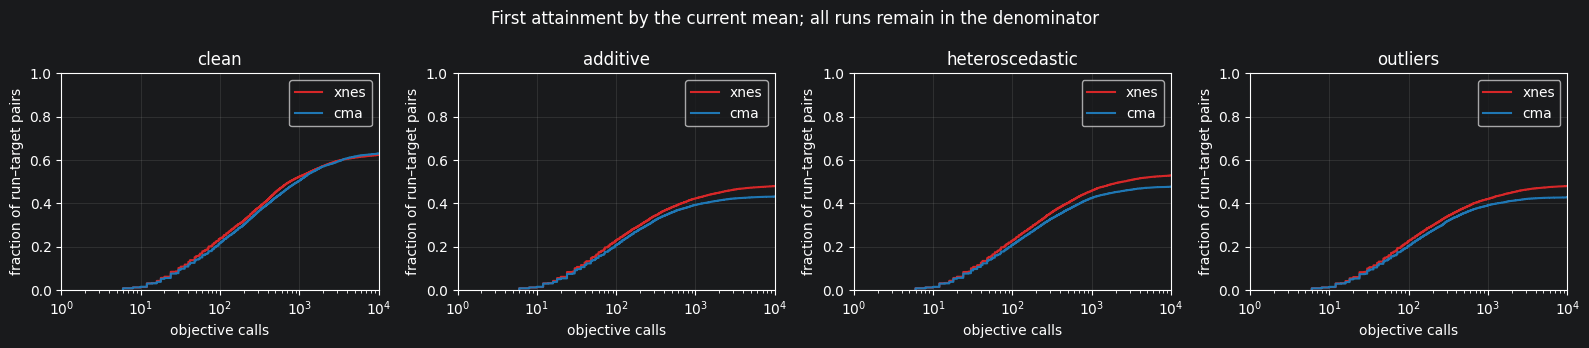

In [17]:
# First attainment is not sustained convergence; a noisy trajectory can deteriorate afterward.
# All run-target pairs, including unreached targets and failures, remain in the denominator.
plot_targets(results)
plt.show()

## Stability without recovery

Constant scores exercise actual tie handling. Independent random scores exercise random rankings. Neither contains optimization signal: drift is measured, not judged against an invented threshold. Initial scales are randomly rotated with geometric-mean scale 1 and axis ratios 1, 10⁶, and 10⁹. Dimensions are 2, 10, and 30.

The first terminal status ends each run. No exception is swallowed as a success. Diagnostic JSON files contain the pre-update distribution, population, scores, and xNES standardized samples needed to replay a failed update.

xNES stability:   0%|          | 0/270 [00:00<?, ?it/s]

,dimension,initial_axis_ratio,repeat,noise,kind,reason,evaluations,max_mean_drift,max_axis_ratio,final_scale_global,warning_count
0,2,1.000000e+00,0,constant,budget,Insufficient budget for another complete popul...,9996,100259.854006,1.027334e+04,3.305787,0
1,2,1.000000e+00,1,constant,budget,Insufficient budget for another complete popul...,9996,10316.973312,2.484916e+03,2.396550,0
2,2,1.000000e+00,2,constant,budget,Insufficient budget for another complete popul...,9996,116622.039481,2.315514e+02,4.996929,0
3,2,1.000000e+00,3,constant,budget,Insufficient budget for another complete popul...,9996,811.352264,1.712411e+03,0.004176,0
4,2,1.000000e+00,4,constant,budget,Insufficient budget for another complete popul...,9996,3151.919466,1.653026e+04,0.038001,0
...,...,...,...,...,...,...,...,...,...,...,...
265,30,1.000000e+09,10,random,budget,Insufficient budget for another complete popul...,9996,284034.524588,1.040852e+09,0.862584,0
266,30,1.000000e+09,11,random,budget,Insufficient budget for another complete popul...,9996,859665.303082,1.196890e+09,0.750934,0
267,30,1.000000e+09,12,random,budget,Insufficient budget for another complete popul...,9996,939419.924651,1.114982e+09,1.606369,0
268,30,1.000000e+09,13,random,budget,Insufficient budget for another complete popul...,9996,616352.080107,1.070964e+09,1.449201,0


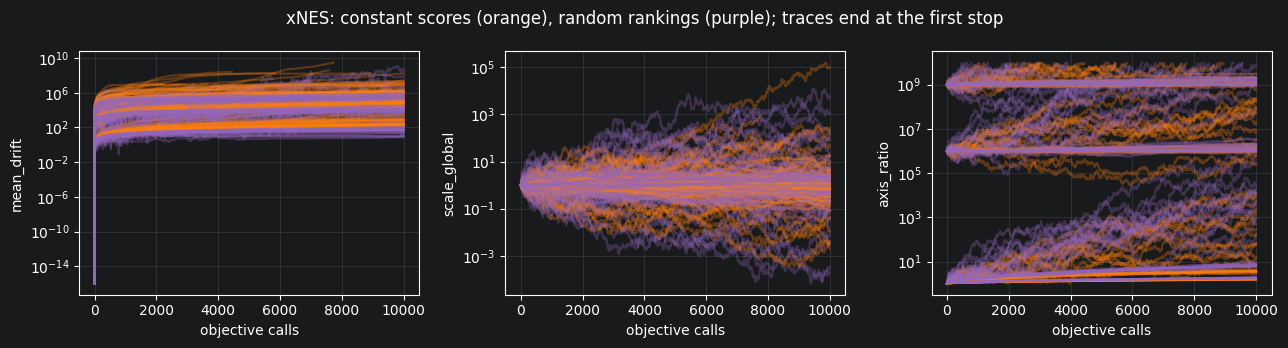

In [18]:
if LOAD_RUN is None:
    stability = run_stability(config, run_dir)
else:
    stability = load_runs(run_dir, "stability-*.json")
stability_table = run_table(stability)
display(stability_table[[
    "dimension", "initial_axis_ratio", "repeat", "noise", "kind", "reason", "evaluations",
    "max_mean_drift", "max_axis_ratio", "final_scale_global", "warning_count"
]])
plot_stability(stability)
plt.show()

## Reading and reproducing the results

Every run is written immediately under a unique `runs/` directory; nothing is deleted. The manifest records configuration, seeds (also per run), package versions, current xNES learning-rate defaults, revision, and source hashes. JSON includes complete generation diagnostics and terminal warnings/errors.

Set `LOAD_RUN` above to regenerate these reports. When comparing revisions, use identical problem/noise configurations. These experiments establish behavior only for the specified landscapes, noise distributions, dimensions, and budgets—not a universal ranking. The workbench is for quick experiments; parameter sweeps are training experiments and should not be used as held-out evidence.